# Artificial Neural Network (ANN) Using PyTorch for MNIST Classification

## Project Objective

Projek ini membangunkan Artificial Neural Network (ANN) menggunakan PyTorch
untuk mengklasifikasikan imej digit tulisan tangan daripada dataset MNIST.

Model ANN menggunakan:
- Input Layer
- One Hidden Layer
- Output Layer
- ReLU Activation Function
- CrossEntropyLoss
- Adam Optimizer

Projek ini juga menjalankan hyperparameter tuning dengan mengubah learning rate
dan membandingkan keputusan sebelum dan selepas tuning.

In [24]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
# Library yang digunakan untuk membina, melatih dan menilai ANN.

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random

# Menetapkan random seed untuk membantu mendapatkan keputusan yang konsisten.
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("==========================================")
print("IMPORT LIBRARIES")
print("==========================================")
print("PyTorch        : Berjaya")
print("Torchvision    : Berjaya")
print("Matplotlib     : Berjaya")
print("NumPy          : Berjaya")
print("==========================================")

IMPORT LIBRARIES
PyTorch        : Berjaya
Torchvision    : Berjaya
Matplotlib     : Berjaya
NumPy          : Berjaya


CHECK DEVICE

In [25]:
# ============================================================
# CHECK DEVICE
# ============================================================
# Menentukan sama ada model akan menggunakan GPU atau CPU.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("==========================================")
print("DEVICE INFORMATION")
print("==========================================")
print("Device yang digunakan:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU tidak tersedia.")
    print("Model akan menggunakan CPU.")

print("==========================================")

DEVICE INFORMATION
Device yang digunakan: cpu
GPU tidak tersedia.
Model akan menggunakan CPU.


## 4. Load MNIST Dataset

Dataset MNIST mengandungi imej digit tulisan tangan daripada 0 hingga 9.

Setiap imej mempunyai saiz 28 × 28 piksel.

In [26]:
# ============================================================
# LOAD MNIST DATASET
# ============================================================
# ToTensor() menukarkan imej kepada tensor PyTorch.
# Nilai piksel akan berada dalam julat 0 hingga 1.

transform = transforms.ToTensor()

# Dataset latihan.
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Dataset ujian.
test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("==========================================")
print("MNIST DATASET")
print("==========================================")
print("Jumlah data latihan:", len(train_dataset))
print("Jumlah data ujian  :", len(test_dataset))
print("Bilangan kelas     : 10")
print("Kelas              : 0 hingga 9")
print("==========================================")

MNIST DATASET
Jumlah data latihan: 60000
Jumlah data ujian  : 10000
Bilangan kelas     : 10
Kelas              : 0 hingga 9


## 5. Data Preprocessing

Imej MNIST mempunyai saiz 28 × 28 piksel.

Sebelum dimasukkan ke ANN, imej akan diratakan (flatten) menjadi satu vektor
784 nilai kerana:

28 × 28 = 784

In [27]:
# ============================================================
# DATA PREPROCESSING
# ============================================================
# Imej MNIST mempunyai saiz 28 x 28.
# Untuk ANN, imej akan diratakan menjadi 784 input features.
#
# 28 x 28 = 784
#
# Proses flatten akan dilakukan di dalam fungsi forward()
# model ANN.

sample_image, sample_label = train_dataset[0]

print("==========================================")
print("DATA PREPROCESSING")
print("==========================================")
print("Saiz imej asal       :", sample_image.shape)
print("Jumlah input features:", 28 * 28)
print("Label contoh         :", sample_label)
print("==========================================")

DATA PREPROCESSING
Saiz imej asal       : torch.Size([1, 28, 28])
Jumlah input features: 784
Label contoh         : 5


## 6. Visualize MNIST Sample

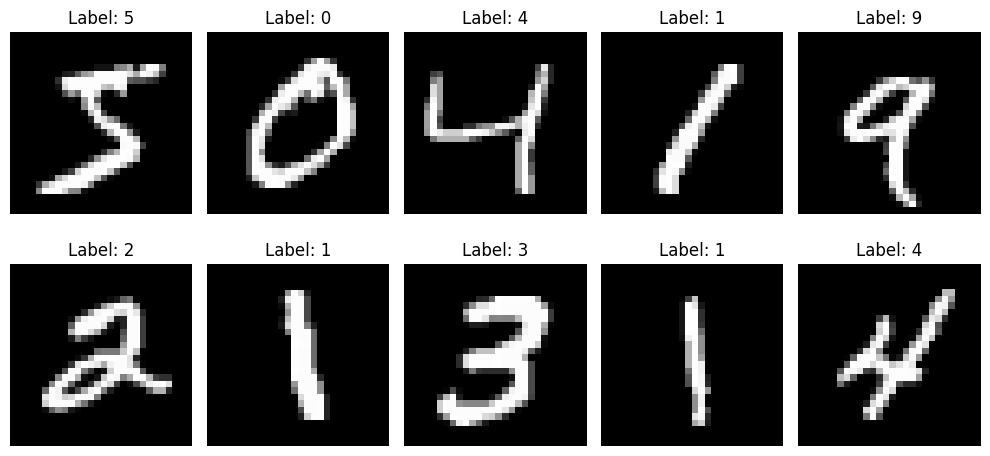

In [28]:
# ============================================================
# VISUALIZE MNIST SAMPLE
# ============================================================
# Memaparkan beberapa contoh imej daripada dataset MNIST.

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):

    # Ambil imej dan label.
    image, label = train_dataset[i]

    # Paparkan imej dalam grayscale.
    ax.imshow(image.squeeze(), cmap="gray")

    # Paparkan label digit.
    ax.set_title(f"Label: {label}")

    # Buang paksi.
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. DataLoader

DataLoader digunakan untuk membahagikan dataset kepada batch supaya proses
training dapat dilakukan dengan lebih teratur.

In [29]:
# ============================================================
# DATALOADER
# ============================================================
# DataLoader membahagikan dataset kepada batch.
# Batch size = 64 bermaksud 64 imej diproses pada satu masa.

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("==========================================")
print("DATALOADER")
print("==========================================")
print("Batch size:", batch_size)
print("Jumlah batch latihan:", len(train_loader))
print("Jumlah batch ujian  :", len(test_loader))
print("==========================================")

DATALOADER
Batch size: 64
Jumlah batch latihan: 938
Jumlah batch ujian  : 157


# 8. Build Artificial Neural Network (ANN)

Struktur ANN yang digunakan:

Input Layer → Hidden Layer → Output Layer

Input Layer  : 784 neurons
Hidden Layer : 128 neurons
Activation   : ReLU
Output Layer : 10 neurons

784 → 128 → 10

In [30]:
# ============================================================
# ARTIFICIAL NEURAL NETWORK (ANN)
# ============================================================
# Struktur ANN:
#
# INPUT LAYER  = 784 neurons
# HIDDEN LAYER = 128 neurons
# OUTPUT LAYER = 10 neurons
#
# Architecture:
#
# 784 → 128 → 10
#
# 784 = 28 x 28 input pixels
# 128 = satu hidden layer
# 10  = kelas digit 0 hingga 9

class SimpleANN(nn.Module):

    def __init__(self):

        # Memanggil constructor daripada nn.Module.
        super(SimpleANN, self).__init__()

        # ----------------------------------------------------
        # INPUT LAYER → HIDDEN LAYER
        # ----------------------------------------------------
        # 784 input features kepada 128 hidden neurons.
        self.fc1 = nn.Linear(28 * 28, 128)

        # ----------------------------------------------------
        # ACTIVATION FUNCTION
        # ----------------------------------------------------
        # ReLU digunakan sebagai activation function.
        self.relu = nn.ReLU()

        # ----------------------------------------------------
        # HIDDEN LAYER → OUTPUT LAYER
        # ----------------------------------------------------
        # 128 hidden neurons kepada 10 output classes.
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        # ----------------------------------------------------
        # FLATTEN INPUT
        # ----------------------------------------------------
        # Imej 28 x 28 ditukarkan kepada 784 features.
        x = x.view(x.size(0), -1)

        # ----------------------------------------------------
        # FORWARD PROPAGATION
        # Input Layer → Hidden Layer
        # ----------------------------------------------------
        x = self.fc1(x)

        # ----------------------------------------------------
        # ACTIVATION
        # ----------------------------------------------------
        x = self.relu(x)

        # ----------------------------------------------------
        # FORWARD PROPAGATION
        # Hidden Layer → Output Layer
        # ----------------------------------------------------
        x = self.fc2(x)

        return x

In [31]:
# ============================================================
# CREATE ANN MODEL
# ============================================================

model = SimpleANN().to(device)

print("================================================")
print("          ARTIFICIAL NEURAL NETWORK (ANN)")
print("================================================")

# Paparkan struktur model ANN.
print(model)

print()
print("------------- ANN ARCHITECTURE ----------------")
print("Input Layer      : 784 neurons")
print("Hidden Layer     : 128 neurons")
print("Activation       : ReLU")
print("Output Layer     : 10 neurons")
print("Architecture     : 784 → 128 → 10")
print("================================================")

          ARTIFICIAL NEURAL NETWORK (ANN)
SimpleANN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

------------- ANN ARCHITECTURE ----------------
Input Layer      : 784 neurons
Hidden Layer     : 128 neurons
Activation       : ReLU
Output Layer     : 10 neurons
Architecture     : 784 → 128 → 10


## 9. ANN Configuration

Model ANN menggunakan satu hidden layer dengan ReLU activation function.
Loss function ialah CrossEntropyLoss dan optimizer ialah Adam.

In [32]:
# ============================================================
# ANN CONFIGURATION
# ============================================================
# Cell ini menunjukkan semua komponen utama ANN.

input_neurons = 784
hidden_neurons = 128
output_neurons = 10

activation_function = "ReLU"
loss_function_name = "CrossEntropyLoss"
optimizer_name = "Adam"

learning_rate = 0.0001
epochs = 5
batch_size = 64

print("================================================")
print("              ANN CONFIGURATION")
print("================================================")

print("Input Layer      :", input_neurons, "neurons")
print("Hidden Layer     :", hidden_neurons, "neurons")
print("Output Layer     :", output_neurons, "neurons")
print("Activation       :", activation_function)
print("Loss Function    :", loss_function_name)
print("Optimizer        :", optimizer_name)
print("Learning Rate    :", learning_rate)
print("Batch Size       :", batch_size)
print("Epochs           :", epochs)

print("================================================")

              ANN CONFIGURATION
Input Layer      : 784 neurons
Hidden Layer     : 128 neurons
Output Layer     : 10 neurons
Activation       : ReLU
Loss Function    : CrossEntropyLoss
Optimizer        : Adam
Learning Rate    : 0.0001
Batch Size       : 64
Epochs           : 5


## 10. Loss Function and Optimizer

CrossEntropyLoss digunakan untuk mengira kesalahan prediction model.

Adam digunakan sebagai optimizer untuk mengemaskini weights model semasa
proses training.

In [33]:
# ============================================================
# LOSS FUNCTION
# ============================================================
# CrossEntropyLoss digunakan untuk klasifikasi multi-class.
# MNIST mempunyai 10 kelas iaitu digit 0 hingga 9.

criterion = nn.CrossEntropyLoss()

# ============================================================
# [BUKTI 6.1.4] OPTIMIZER
# ============================================================
# Adam digunakan untuk mengemaskini weights/parameter ANN
# berdasarkan gradient yang diperoleh semasa training.

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print("==========================================")
print("LOSS FUNCTION & OPTIMIZER")
print("==========================================")
print("Loss Function:", criterion)
print("Optimizer    :", optimizer)
print("Learning Rate:", learning_rate)
print("==========================================")

LOSS FUNCTION & OPTIMIZER
Loss Function: CrossEntropyLoss()
Optimizer    : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Learning Rate: 0.0001


# 10. Baseline Training

Model akan dilatih menggunakan:
- Learning Rate = 0.0001
- Batch Size = 64
- Epochs = 5
- Optimizer = Adam

In [34]:
# ============================================================
# BASELINE TRAINING
# ============================================================
# Training ANN mengandungi empat proses utama:
#
# 1. Forward propagation
# 2. Calculate loss
# 3. Backward propagation
# 4. Update weights
#
# Model:
# 784 → 128 → 10
#
# Activation:
# ReLU
#
# Loss:
# CrossEntropyLoss
#
# Optimizer:
# Adam

num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    # Letakkan model dalam training mode.
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Hantar data ke CPU/GPU.
        images = images.to(device)
        labels = labels.to(device)

        # ----------------------------------------------------
        # 1. ZERO GRADIENT
        # ----------------------------------------------------
        optimizer.zero_grad()

        # ----------------------------------------------------
        # 2. FORWARD PROPAGATION
        # ----------------------------------------------------
        outputs = model(images)

        # ----------------------------------------------------
        # 3. CALCULATE LOSS
        # ----------------------------------------------------
        loss = criterion(outputs, labels)

        # ----------------------------------------------------
        # 4. BACKWARD PROPAGATION
        # ----------------------------------------------------
        loss.backward()

        # ----------------------------------------------------
        # 5. UPDATE WEIGHTS
        # ----------------------------------------------------
        optimizer.step()

        # Simpan jumlah loss.
        running_loss += loss.item()

        # Dapatkan prediction.
        _, predicted = torch.max(outputs.data, 1)

        # Jumlah data.
        total += labels.size(0)

        # Jumlah prediction betul.
        correct += (predicted == labels).sum().item()

    # Purata loss.
    epoch_loss = running_loss / len(train_loader)

    # Accuracy.
    epoch_accuracy = 100 * correct / total

    # Simpan untuk graph.
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

print()
print("==========================================")
print("BASELINE TRAINING SELESAI")
print("==========================================")

Epoch [1/5] Loss: 0.8806 Accuracy: 81.06%
Epoch [2/5] Loss: 0.3705 Accuracy: 90.11%
Epoch [3/5] Loss: 0.3104 Accuracy: 91.35%
Epoch [4/5] Loss: 0.2791 Accuracy: 92.17%
Epoch [5/5] Loss: 0.2560 Accuracy: 92.76%

BASELINE TRAINING SELESAI


# 11. Testing Accuracy

Selepas training, model diuji menggunakan test dataset MNIST yang mengandungi
10,000 imej.

In [35]:
# ============================================================
# TESTING ACCURACY
# ============================================================
# Model diuji menggunakan test dataset.
# Target assignment: accuracy sekurang-kurangnya 80%.

model.eval()

correct = 0
total = 0

# Gradient tidak diperlukan semasa testing.
with torch.no_grad():

    for images, labels in test_loader:

        # Hantar data ke device.
        images = images.to(device)
        labels = labels.to(device)

        # Buat prediction.
        outputs = model(images)

        # Ambil class dengan nilai tertinggi.
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("==========================================")
print("        BASELINE TESTING RESULT")
print("==========================================")
print(f"Testing Accuracy: {test_accuracy:.2f}%")

if test_accuracy >= 80:
    print("STATUS: LULUS - Accuracy mencapai benchmark 80%")
else:
    print("STATUS: BELUM MENCAPAI benchmark 80%")

print("==========================================")

        BASELINE TESTING RESULT
Testing Accuracy: 93.14%
STATUS: LULUS - Accuracy mencapai benchmark 80%


# 12. Training Loss Graph

Graf loss digunakan untuk menunjukkan sama ada model ANN semakin belajar
dengan baik sepanjang proses training.

Loss yang semakin menurun menunjukkan model sedang melakukan convergence.

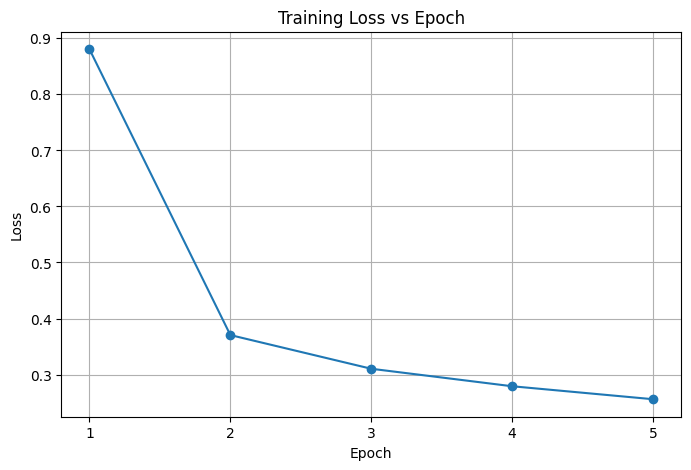

In [36]:
# ============================================================
# LOSS VS EPOCH
# ============================================================
# Graph ini menunjukkan perubahan loss sepanjang training.
# Loss yang semakin menurun menunjukkan model sedang belajar
# dan menuju convergence.

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)

plt.show()

# 13. Training Accuracy Graph

Graf accuracy menunjukkan peningkatan ketepatan model sepanjang training.

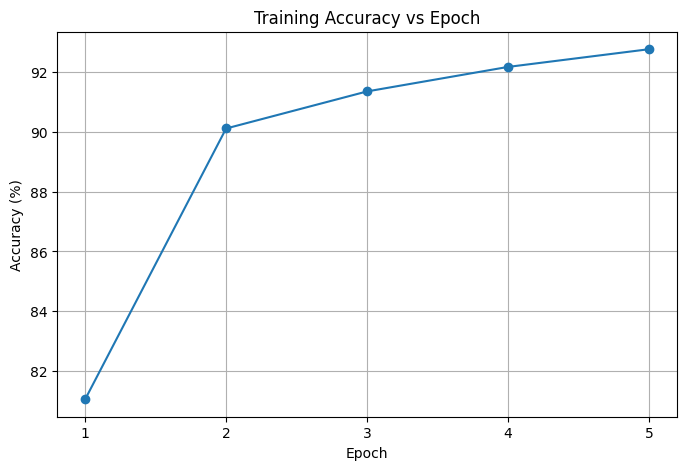

In [37]:
# ============================================================
# ACCURACY VS EPOCH
# ============================================================
# Graph menunjukkan perubahan accuracy model sepanjang
# proses training.

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker="o"
)

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)

plt.show()

# 14. Hyperparameter Tuning

Untuk hyperparameter tuning, hanya learning rate diubah.

Baseline:
Learning Rate = 0.0001

Tuned:
Learning Rate = 0.001

Parameter lain dikekalkan sama supaya perbandingan lebih adil.

In [38]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================
# Hanya Learning Rate diubah.
# Parameter lain dikekalkan sama untuk perbandingan yang adil.

baseline_lr = 0.0001
tuned_lr = 0.001

print("==========================================")
print("HYPERPARAMETER TUNING")
print("==========================================")

print("Parameter diubah : Learning Rate")
print("Before Tuning    :", baseline_lr)
print("After Tuning     :", tuned_lr)

print()
print("Parameter lain dikekalkan:")
print("Hidden Layer     : 128")
print("Activation       : ReLU")
print("Optimizer        : Adam")
print("Batch Size       : 64")
print("Epochs           : 5")

print("==========================================")

HYPERPARAMETER TUNING
Parameter diubah : Learning Rate
Before Tuning    : 0.0001
After Tuning     : 0.001

Parameter lain dikekalkan:
Hidden Layer     : 128
Activation       : ReLU
Optimizer        : Adam
Batch Size       : 64
Epochs           : 5


# 15. Tuned Training

Model ANN baharu digunakan supaya training bermula daripada keadaan awal yang
sama dan hanya learning rate yang berbeza.

In [39]:
# ============================================================
# TUNED TRAINING
# ============================================================
# Model ANN baharu digunakan.
# Architecture masih sama:
#
# 784 → 128 → 10
#
# Hanya Learning Rate berubah:
#
# 0.0001 → 0.001

tuned_model = SimpleANN().to(device)

# Loss function masih sama.
tuned_criterion = nn.CrossEntropyLoss()

# Optimizer masih Adam tetapi menggunakan learning rate baharu.
tuned_optimizer = optim.Adam(
    tuned_model.parameters(),
    lr=tuned_lr
)

tuned_losses = []
tuned_accuracies = []

for epoch in range(num_epochs):

    tuned_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Zero gradient.
        tuned_optimizer.zero_grad()

        # Forward propagation.
        outputs = tuned_model(images)

        # Calculate loss.
        loss = tuned_criterion(outputs, labels)

        # Backward propagation.
        loss.backward()

        # Update weights.
        tuned_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    tuned_losses.append(epoch_loss)
    tuned_accuracies.append(epoch_accuracy)

    print(
        f"Tuned Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

print()
print("==========================================")
print("TUNED TRAINING SELESAI")
print("==========================================")

Tuned Epoch [1/5] Loss: 0.3455 Accuracy: 90.63%
Tuned Epoch [2/5] Loss: 0.1605 Accuracy: 95.31%
Tuned Epoch [3/5] Loss: 0.1109 Accuracy: 96.75%
Tuned Epoch [4/5] Loss: 0.0840 Accuracy: 97.58%
Tuned Epoch [5/5] Loss: 0.0658 Accuracy: 98.05%

TUNED TRAINING SELESAI


TUNED TESTING ACCURACY

In [40]:
# ============================================================
# TUNED TESTING ACCURACY
# ============================================================
# Menguji model selepas Learning Rate diubah kepada 0.001.

tuned_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Prediction.
        outputs = tuned_model(images)

        # Ambil prediction tertinggi.
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

tuned_test_accuracy = 100 * correct / total

print("==========================================")
print("          TUNED TESTING RESULT")
print("==========================================")
print(f"Tuned Testing Accuracy: {tuned_test_accuracy:.2f}%")

if tuned_test_accuracy >= 80:
    print("STATUS: LULUS - Accuracy mencapai benchmark 80%")
else:
    print("STATUS: BELUM MENCAPAI benchmark 80%")

print("==========================================")

          TUNED TESTING RESULT
Tuned Testing Accuracy: 97.37%
STATUS: LULUS - Accuracy mencapai benchmark 80%


BEFORE VS AFTER COMPARISON

In [41]:
# ============================================================
# BEFORE VS AFTER HYPERPARAMETER TUNING
# ============================================================
# Membandingkan keputusan model sebelum dan selepas
# Learning Rate diubah.

improvement = tuned_test_accuracy - test_accuracy

print("================================================")
print("       HYPERPARAMETER TUNING COMPARISON")
print("================================================")

print(f"Before Tuning")
print(f"Learning Rate : {baseline_lr}")
print(f"Accuracy      : {test_accuracy:.2f}%")

print()

print(f"After Tuning")
print(f"Learning Rate : {tuned_lr}")
print(f"Accuracy      : {tuned_test_accuracy:.2f}%")

print()

print(f"Accuracy Improvement : {improvement:.2f}%")

print("================================================")

if improvement > 0:
    print("Result: Accuracy meningkat selepas tuning.")
elif improvement < 0:
    print("Result: Accuracy menurun selepas tuning.")
else:
    print("Result: Accuracy tidak berubah.")

print("================================================")

       HYPERPARAMETER TUNING COMPARISON
Before Tuning
Learning Rate : 0.0001
Accuracy      : 93.14%

After Tuning
Learning Rate : 0.001
Accuracy      : 97.37%

Accuracy Improvement : 4.23%
Result: Accuracy meningkat selepas tuning.


# 18. Before vs After Hyperparameter Tuning

Graf ini membandingkan testing accuracy antara model baseline dan model selepas
hyperparameter tuning.

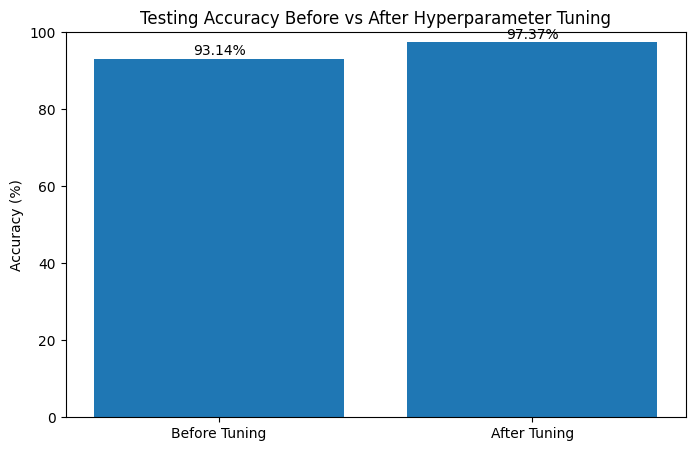

In [42]:
# ============================================================
# BEFORE VS AFTER COMPARISON GRAPH
# ============================================================
# Graph ini membandingkan testing accuracy sebelum dan
# selepas hyperparameter tuning.

labels = [
    "Before Tuning",
    "After Tuning"
]

accuracies = [
    test_accuracy,
    tuned_test_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    accuracies
)

plt.title("Testing Accuracy Before vs After Hyperparameter Tuning")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Paparkan nilai accuracy di atas bar.
for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

COMPARE LOSS

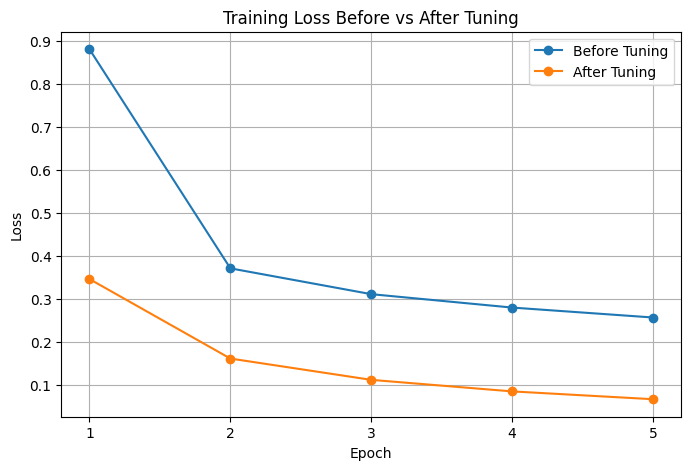

In [43]:
# ============================================================
# LOSS COMPARISON
# ============================================================
# Membandingkan training loss sebelum dan selepas tuning.

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o",
    label="Before Tuning"
)

plt.plot(
    range(1, num_epochs + 1),
    tuned_losses,
    marker="o",
    label="After Tuning"
)

plt.title("Training Loss Before vs After Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, num_epochs + 1))
plt.legend()
plt.grid(True)

plt.show()

# 19. KEPUTUSAN AKHIR

Projek ini berjaya membangunkan Artificial Neural Network (ANN) menggunakan
PyTorch untuk mengklasifikasikan dataset MNIST.

Struktur ANN yang digunakan ialah:

784 → 128 → 10

Model mempunyai:
- Input Layer = 784 neurons
- One Hidden Layer = 128 neurons
- Activation Function = ReLU
- Output Layer = 10 neurons
- Loss Function = CrossEntropyLoss
- Optimizer = Adam

Model dilatih menggunakan MNIST dan testing accuracy digunakan untuk menilai
prestasi model.

Hyperparameter tuning dilakukan dengan mengubah Learning Rate daripada 0.0001
kepada 0.001. Keputusan sebelum dan selepas tuning dibandingkan menggunakan
testing accuracy.

Training loss dan training accuracy turut diplot menggunakan Matplotlib untuk
menunjukkan perkembangan model sepanjang proses training.